In [40]:
##############
## INITIATE ##
##############

## Imports
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2

## Import modules
from f_wsi_reader import slide_path_to_tiles_at_coordinates
from f_wsi_reader import get_tile_map
from f_wsi_reader import slide_to_tiles_at_coordinates
from f_wsi_reader import read_slide
from f_wsi_reader import get_dimensions
from f_wsi_reader import apply_all_filters
from f_wsi_reader import apply_all_transforms
from f_wsi_reader import reassemble_tiles
from f_wsi_reader import select_patches_on_grid

#
###

In [41]:
###########
## PATHS ##
###########

## Parameters
# wsi_paths = ['/Volumes/SED/BDI/databases/RAW/datasets/PANDA/images/tiff/0a93d9a674e358ba32e4e2ec320aefc5.tiff'] # PANDA example 1
# wsi_paths = ['/Volumes/SED/BDI/databases/RAW/datasets/PANDA/images/tiff/0bfe4af623f6be66a82289e411320773.tiff'] # PANDA example 2
# wsi_paths = ['/Volumes/SED/BDI/databases/RAW/datasets/TCGA/images/svs/TCGA-EJ-5509-01A_2.svs'] # TCGA
# wsi_paths = ['/Volumes/SED/BDI/databases/RAW/datasets/SEGG/images/test/17_A047-4463_153D+-+2017-05-11+09.40.22_TissueTrain_(1.00,46495,20054,8837,6413)/reference/17_A047-4463_153D+-+2017-05-11+09.40.22_TissueTrain_(1.00,46495,20054,8837,6413).png'] # SEGG
wsi_paths = ['/Volumes/SED/BDI/databases/RAW/datasets/SEGG/images/test/EU_7189_16_2D_HandE_TissueTrain_(1.00,49850,30011,6780,4562)/reference/EU_7189_16_2D_HandE_TissueTrain_(1.00,49850,30011,6780,4562).png'] # SEGG
# wsi_paths = ['/Users/willembonnaffe/Desktop/glandseg_examples/test/17_A047-29957_152D+-+2017-05-11+10.06.25_TissueTrain_(1.00,67585,64417,4452,4506)/reference/17_A047-29957_152D+-+2017-05-11+10.06.25_TissueTrain_(1.00,67585,64417,4452,4506).png']

#
###

(4562, 6780)


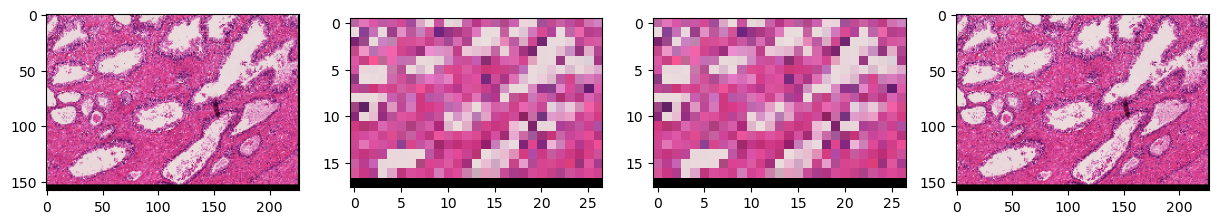

In [42]:
################## 
## GET TILE MAP ##
################## 

## Open slide
slide = read_slide(wsi_paths[0])
slide_size = get_dimensions(slide)
print(slide_size)

## Parameters
tile_size = 256

## Get tile_map
thumbnail, tile_map, canvas_size = get_tile_map(slide, tile_size)

## Extract coordinates of pixels in tile_map that contain tissue
mask = apply_all_filters(tile_map, low=10, std=15, high=200)
mask = apply_all_transforms(mask)

## Get coordinates of tiles with tissue
tile_coordinates = (np.argwhere(mask[:,:,0].T > 0) * tile_size).astype(int)
tile_coordinates = [[tile_coordinate[0], tile_coordinate[1]] for tile_coordinate in tile_coordinates]

## Compute mask
tile_map_masked = tile_map * mask
thumbnail_masked = thumbnail * cv2.resize(mask, (thumbnail.shape[1], thumbnail.shape[0]), cv2.INTER_LINEAR)[:,:,None]
tissue_mask = cv2.resize(mask, (slide_size[1], slide_size[0]), cv2.INTER_LINEAR)[:,:,None]

## Visualise mask
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
axes[0].imshow(thumbnail)
axes[1].imshow(tile_map)
axes[2].imshow(tile_map_masked)
axes[3].imshow(thumbnail_masked)
plt.show()
plt.close()

#
###

Number of patches: 96


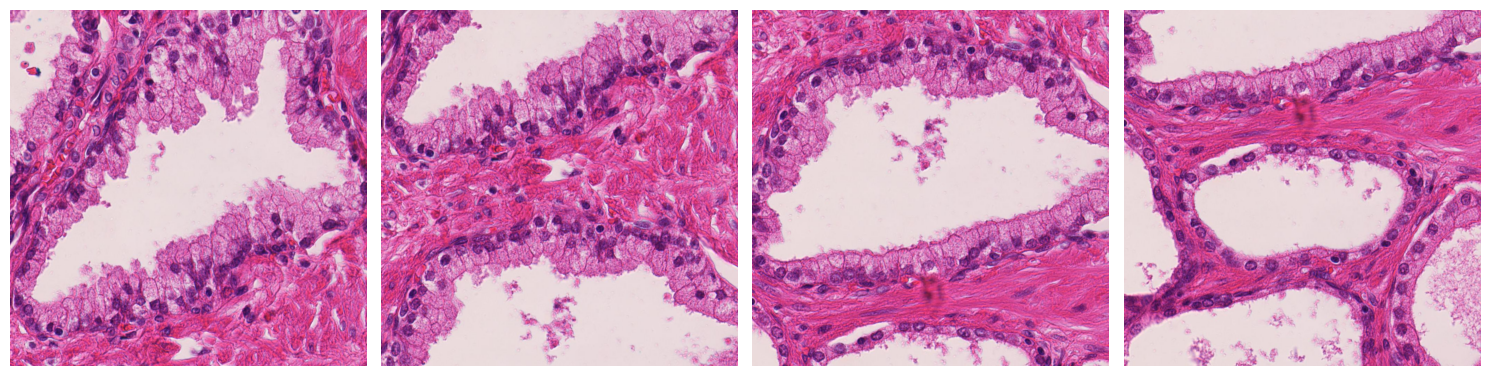

In [43]:
################################
## PATCH EXTRACTION FOR MODEL ##
################################

## Parameters
level = 0
ds = 1
if level > 0: 
    ds = 4 * level
tile_size_ = int(tile_size/ds)# + 64
tile_size_ = 1024

## Remove patches too close to the edges
tile_coordinates_ds = []
for tile_coordinates_ in tile_coordinates:
    coords_0_lo = tile_coordinates_[0] + int(tile_size/2) - int(tile_size_/2)
    coords_0_hi = tile_coordinates_[0] + int(tile_size/2) + int(tile_size_/2)
    coords_1_lo = tile_coordinates_[1] + int(tile_size/2) - int(tile_size_/2)
    coords_1_hi = tile_coordinates_[1] + int(tile_size/2) + int(tile_size_/2)
    if (coords_0_lo > 0) & (coords_0_hi < canvas_size[1]) & (coords_1_lo > 0) & (coords_1_hi < canvas_size[0]):
        tile_coordinates_ds += [[coords_0_lo, coords_1_lo]]

## Get patches closest to grid points
tile_coordinates_ds = select_patches_on_grid(tile_coordinates_ds, grid_spacing=512)
print(f'Number of patches: {len(tile_coordinates_ds)}')

## Load patches from the dataset
patches = slide_path_to_tiles_at_coordinates(wsi_paths[0], tile_coordinates_ds, tile_size_, level) # [dataset[i] for i in range(min(num_patches_to_display, len(dataset)))]

## Display the patches
num_patches_to_display = 4
fig, axes = plt.subplots(1, num_patches_to_display, figsize=(15, 5))
for i, ax in enumerate(axes.flat):
    if i < len(patches):
        ax.imshow(patches[i])
        ax.axis('off')
    else:
        ax.axis('off')  # Hide unused subplots if any
plt.tight_layout()
plt.show()

#
###

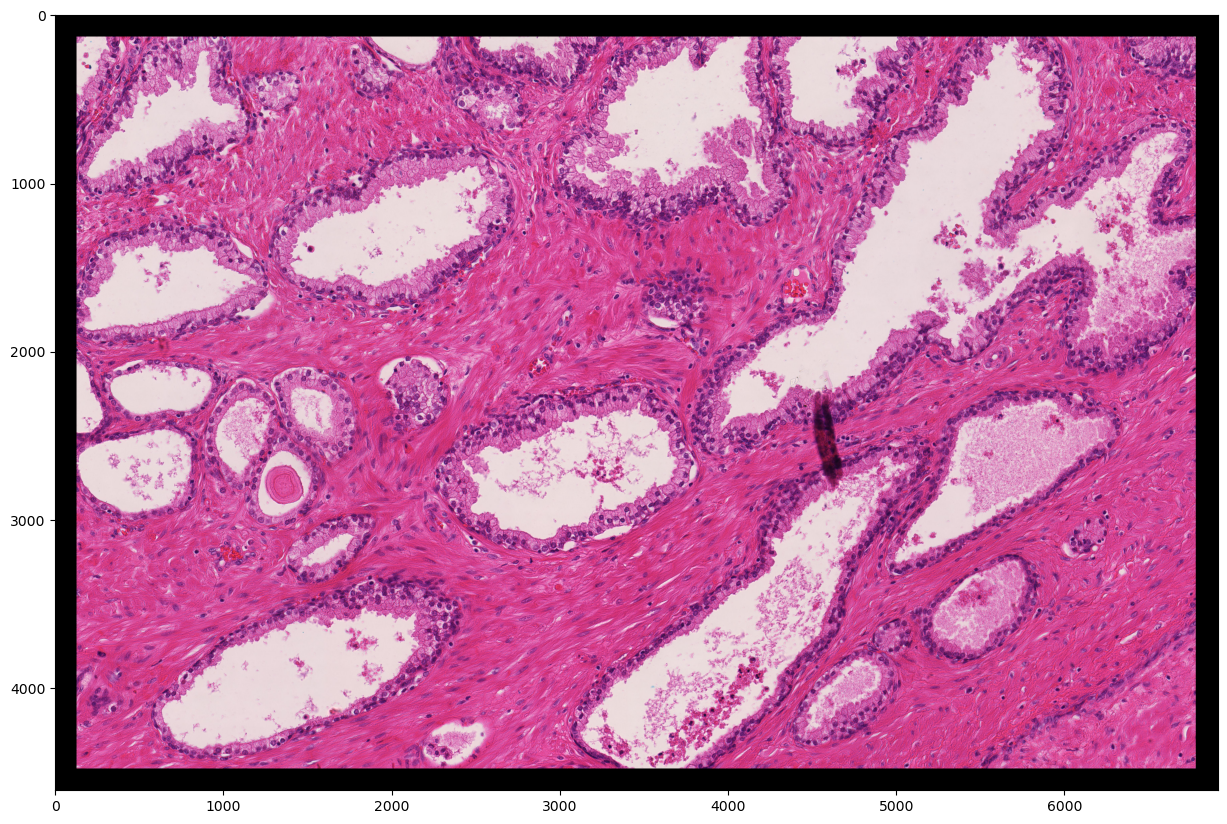

In [44]:
######################
## REASSEMBLE IMAGE ##
######################

## Reassemble image
img = reassemble_tiles(patches, tile_coordinates_ds, canvas_size[1], canvas_size[0])

## Visualise
fig, axes = plt.subplots(1, 1, figsize=(15, 15))
axes.imshow(img)
# axes[1].axis('off')
# axes[2].axis('off')
# axes[3].axis('off')
plt.show()
plt.close()

#
###

In [45]:
#####################################
## FUNCTIONS FOR MODEL APPLICATION ##
#####################################

def numpy_to_device(X):
    tensors = []
    for x in X:        
        x = cv2.resize(x, (1024, 1024))
        x = torch.tensor(x)        
        x = x.swapaxes(2, 1).swapaxes(1, 0) # (H, W, C) --> (C, H, W)
        x = x.float()
        x = x[None, :, :, :] # (C, H, W) --> (B=1, C, H, W)
        x = x.to(device)
        tensors += [x]        
    return tensors

def device_to_numpy(X):
    images = []
    for x in X:
        x = x.cpu().numpy()
        x = x.swapaxes(0, 1).swapaxes(1, 2)    
        x = x.astype('uint8')
        x = cv2.resize(x, (tile_size_, tile_size_))
        images += [x]        
    return images

#
###

In [46]:
#################
## APPLY MODEL ##
#################

## Imports
import torch
import matplotlib.pyplot as plt

## Models
# from f_model import UNet as Model
# pt_model_in = 'models/r10_3.pth'
# num_classes = 4
from f_model_transformer import UNetTransformer as Model
pt_model_in = 'models/TransUNet_V2_0.pth'
num_classes = 3

## Load model
device = "mps"
print(f"Using {device} device")
model = Model(n_classes=num_classes).to(device)
if os.path.exists(pt_model_in):
    model.load_state_dict(torch.load(pt_model_in))
    print("Loaded model")

## Example of iterating through the DataLoader
preds = []
k = 0
X = numpy_to_device(patches)
with torch.no_grad():
    for x in X:                
        Yhat = model(x)        
        Yhat = torch.sigmoid(Yhat) * 255 # Logits to probabilities to [0, 255]
        Yhat = device_to_numpy(Yhat)[0] # Only for single patch
        Yhat = np.argmax(Yhat, axis=2).reshape(Yhat.shape[0], Yhat.shape[1], 1) # Only for multiple classes
        preds += [Yhat]

#
###

Using mps device
Loaded model


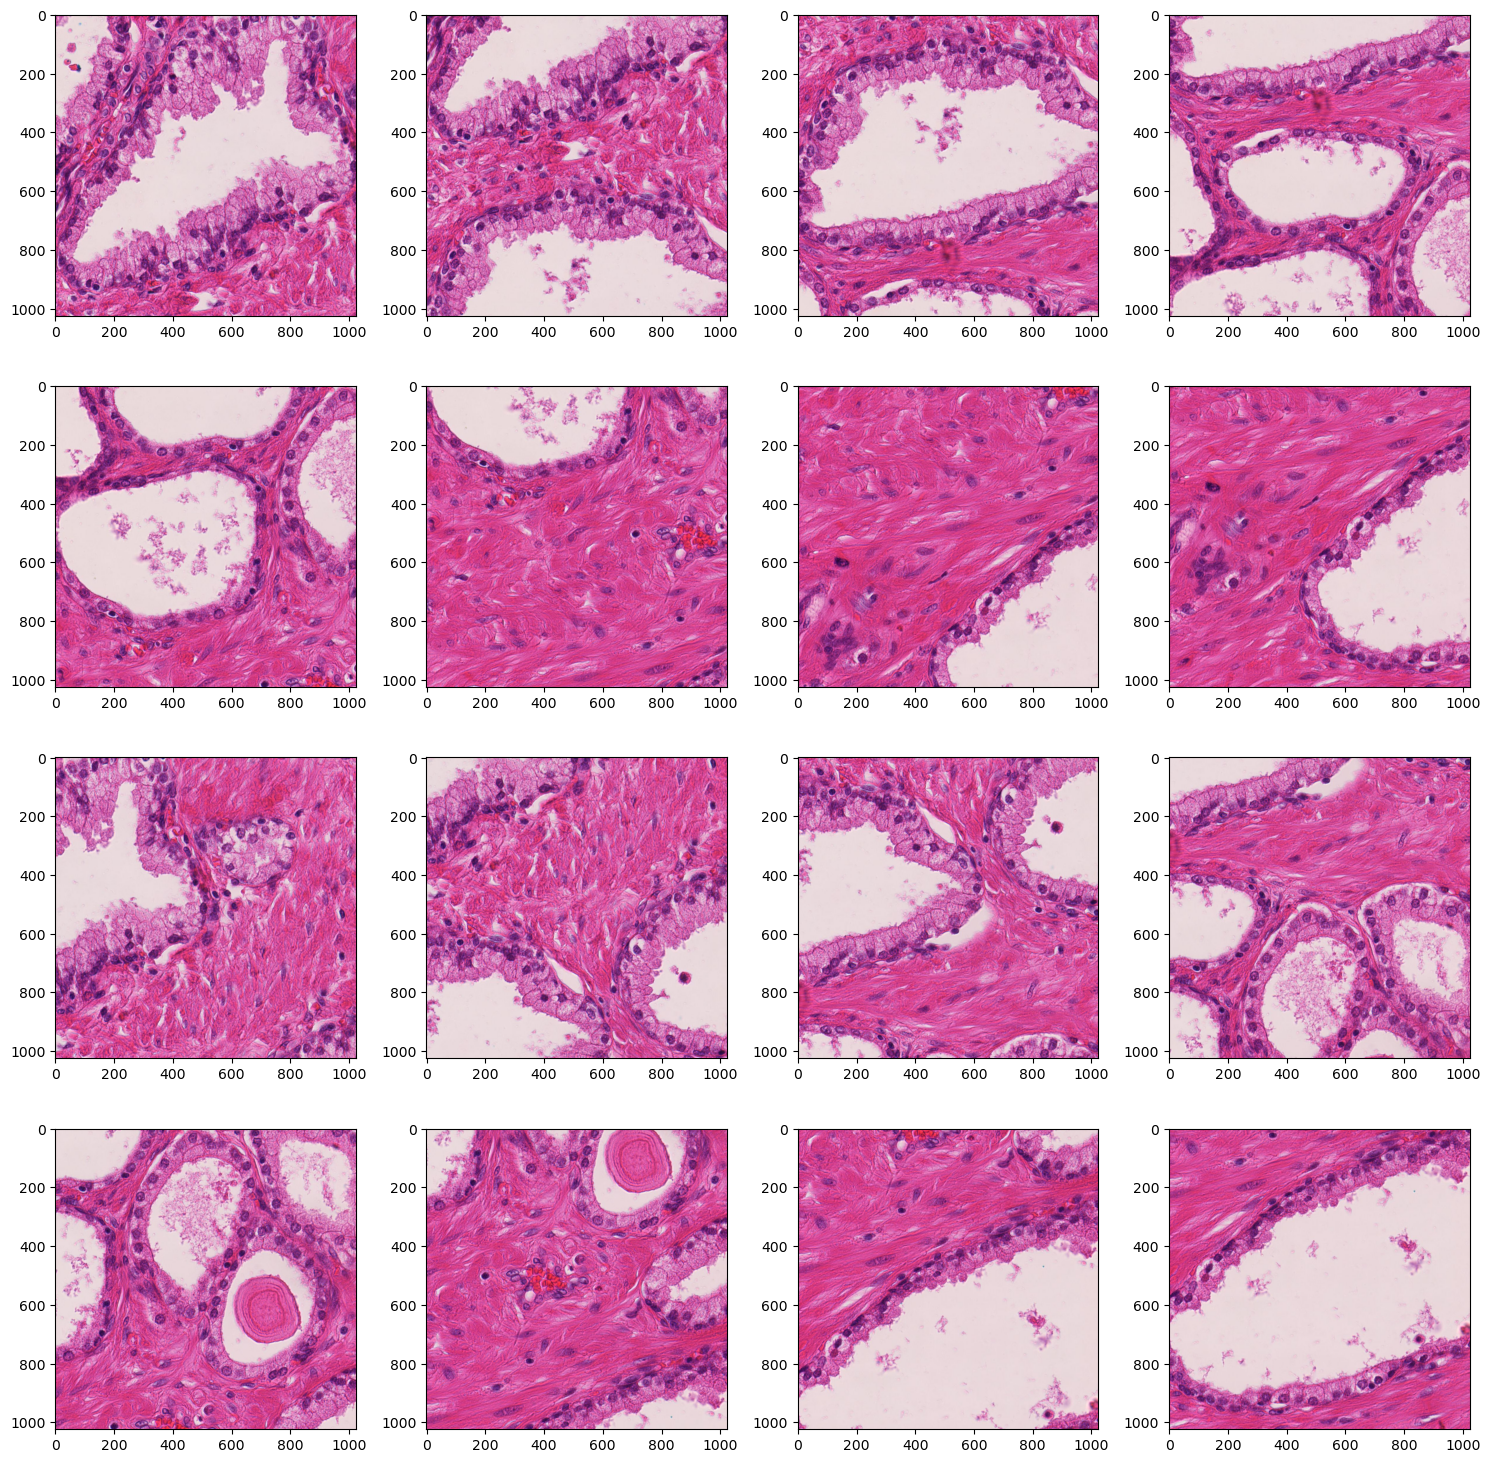

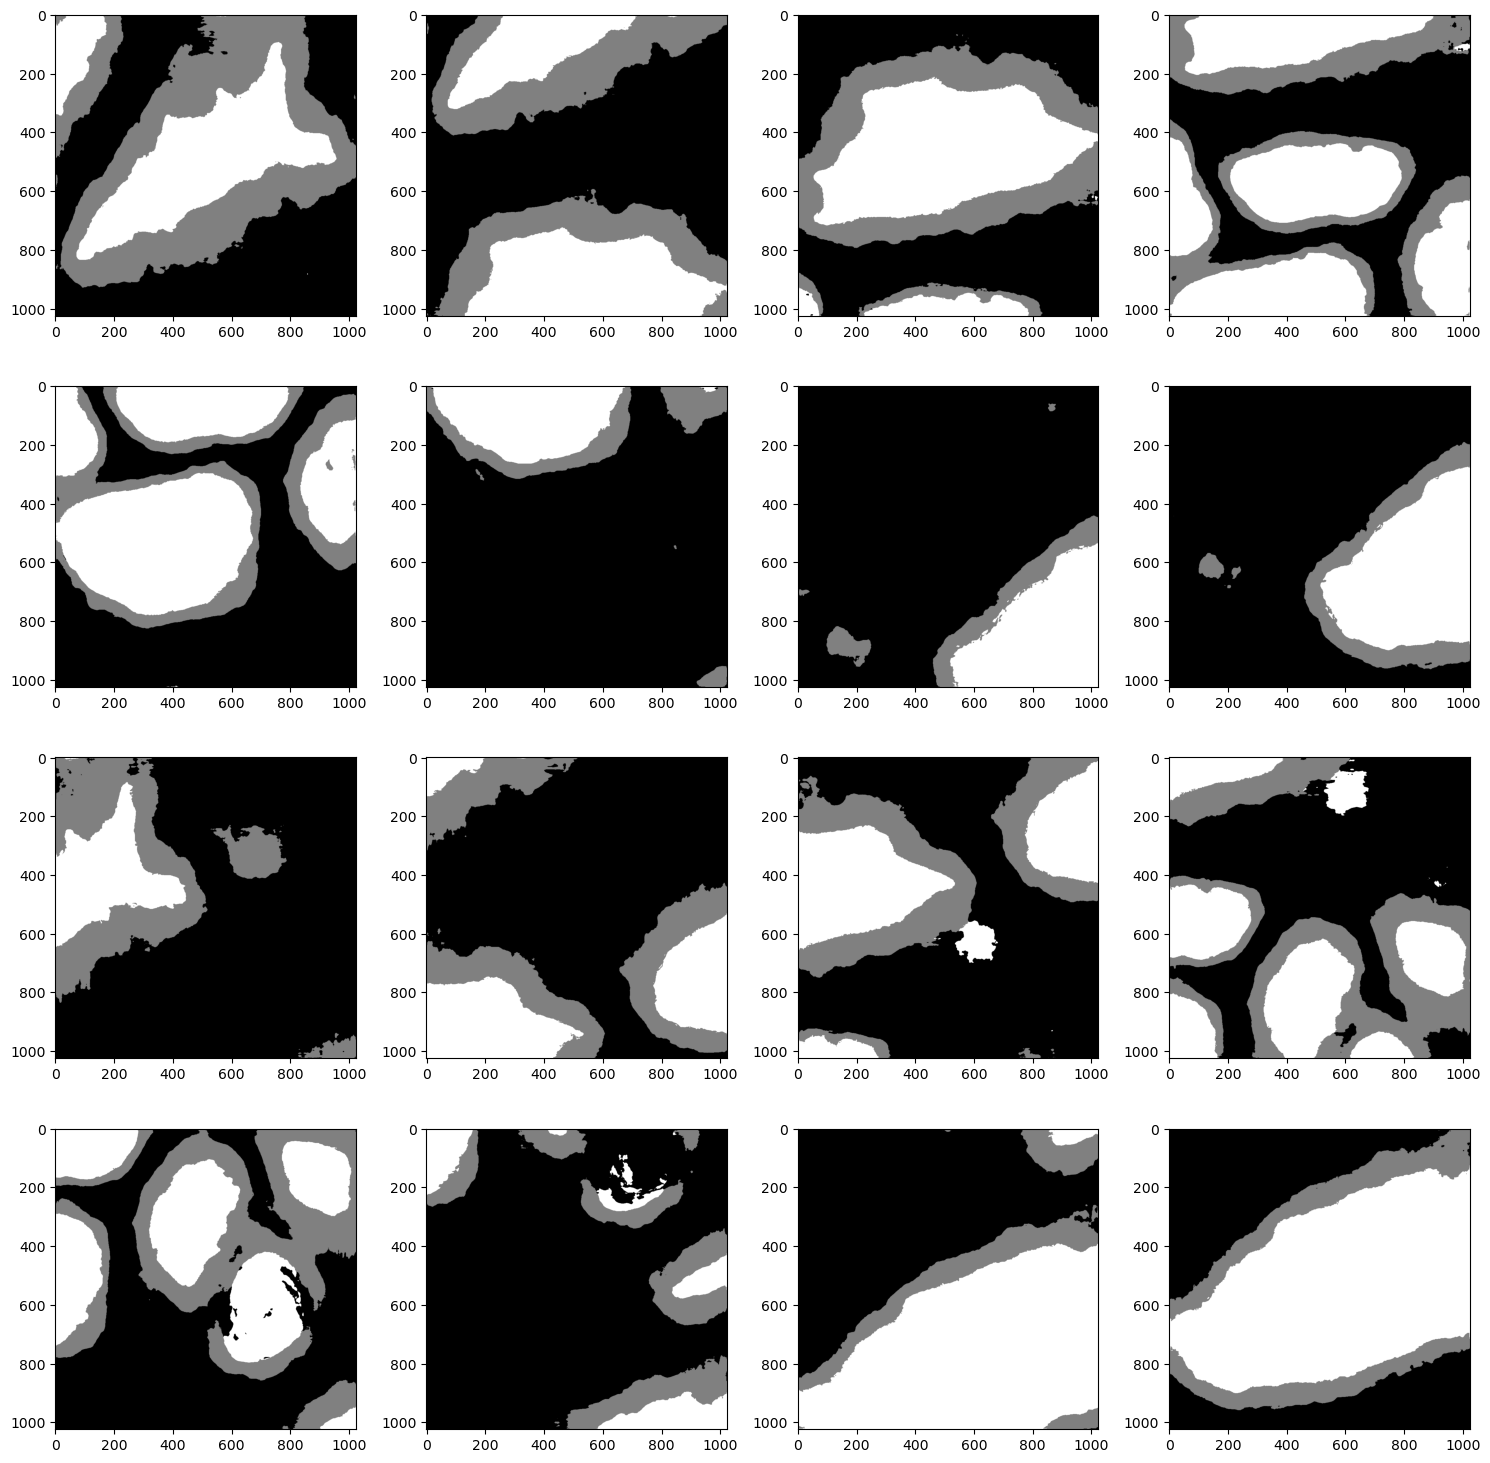

In [47]:
###########################
## VISUALISE PREDICTIONS ##
###########################

## Graphical parameters
from matplotlib.colors import ListedColormap
custom_cmap = 'gist_gray' # ListedColormap(['pink', 'hotpink', 'ivory'])

## Visualise image patches
fig, axes = plt.subplots(4, 4, figsize=(15,15))
k = 0
for i in range(4):
    for j in range(4):
        axis = axes[i,j]        
        axis.imshow(patches[k], cmap=custom_cmap)
        k += 1
plt.tight_layout()
plt.show()
plt.close()

## Visualise prediction patches
fig, axes = plt.subplots(4, 4, figsize=(15,15))
k = 0
for i in range(4):
    for j in range(4):
        axis = axes[i,j]
        axis.imshow(preds[k], cmap=custom_cmap)        
        k += 1
plt.tight_layout()
plt.show()
plt.close()

#
###

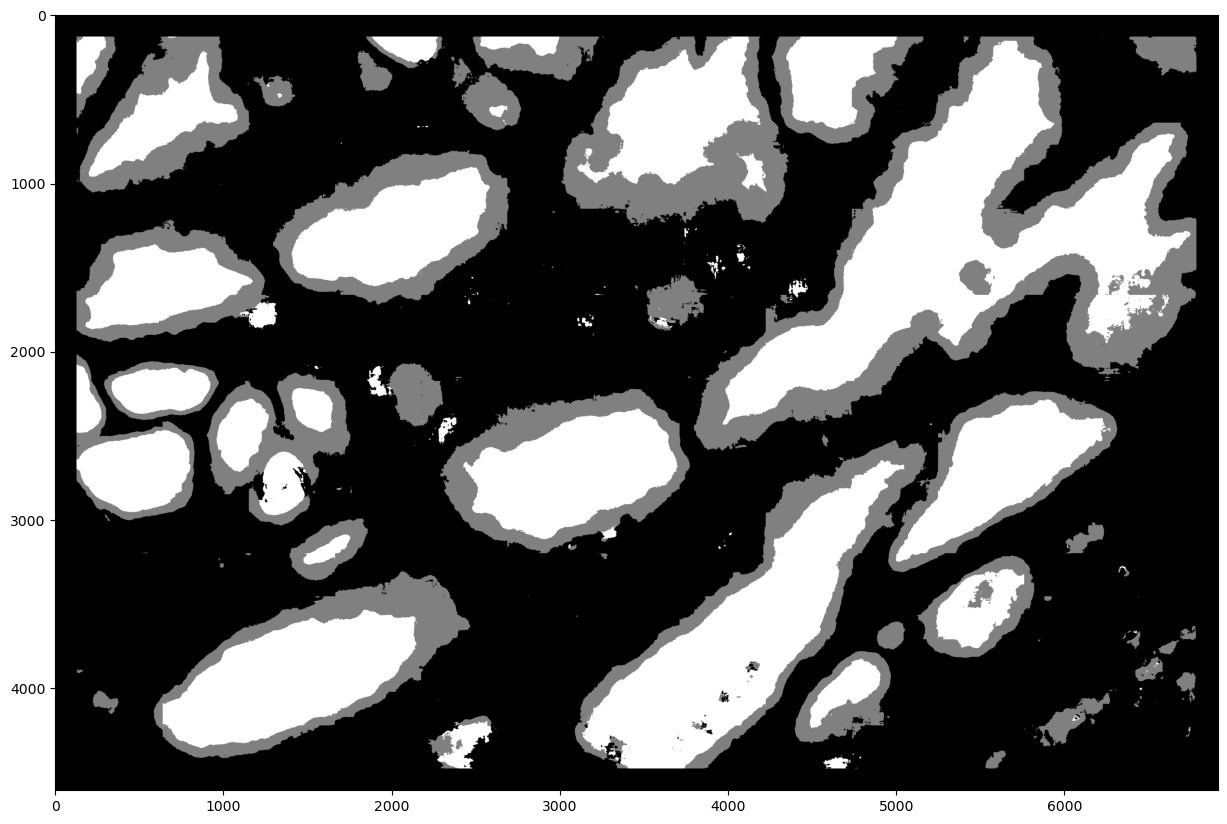

In [48]:
############################
## REASSEMBLE PREDICTIONS ##
############################

## Assemble predictions
mask = reassemble_tiles(preds, tile_coordinates_ds, canvas_size[1], canvas_size[0])
mask = mask[:,:,0].reshape(mask.shape[0], mask.shape[1], 1) 
mask[:tissue_mask.shape[0], :tissue_mask.shape[1]] = mask[:tissue_mask.shape[0], :tissue_mask.shape[1]] * tissue_mask

## Visualise
fig, axes = plt.subplots(1, 1, figsize=(15, 15))
axes.imshow(mask, cmap='gist_gray')
plt.show()
plt.close()

#
###

In [49]:
#####################################
## FUNCTIONS FOR OBJECT EXTRACTION ##
#####################################

## Imports
from f_wsi_reader import overlay_shifted_copies
import numpy as np
import cv2

## polish
## Goal:
## Apply erosion to the image to polish the objects.
## Inputs:
## img (numpy array): Image to apply erosion on.
## Outputs:
## img (numpy array): Eroded image.
def polish(img):
    ## Erosion
    kernel = np.ones((5, 5), np.uint8)  # Adjust the kernel size if needed
    img = cv2.erode(img, kernel, iterations=1)
    img = img.astype(np.uint8)

    # ## Diffusion 
    # for k in range(3):
    #     img = overlay_shifted_copies(img) > 0
    # img = img.astype(np.uint8)
    # img = img.reshape(img.shape[0], img.shape[1], 1)
    
    return img

## extract_object_pixels
## Goal:
## Extract the pixel coordinates of objects from a binary segmentation mask.
## Inputs:
## mask (numpy.ndarray): A 2D binary segmentation mask where objects have a value of 1 (or 255) and background is 0.
## Outputs:
## object_pixels (list): A list of numpy arrays, each containing the (row, column) coordinates of the pixels of each object.
def extract_object_pixels(mask):
    ## Ensure the mask is binary (values are either 0 or 1)
    if mask.max() > 1:
        mask = mask // 255  # Convert 255 values to 1 for consistency if it's an 8-bit mask.

    ## Find connected components (objects) in the mask
    num_labels, labels = cv2.connectedComponents(mask.astype(np.uint8))

    ## Extract pixel coordinates for each object, ignoring the background (label 0)
    object_pixels = []
    for label in range(1, num_labels):
        ## Find pixel coordinates where the label is present
        pixels = np.column_stack(np.where(labels == label))
        object_pixels.append(pixels)

    return object_pixels

## get_bounding_box
## Goal:
## Get the bounding box of an object from its pixel coordinates.
## Inputs:
## coords (numpy.ndarray): Array of (row, column) coordinates of the object's pixels.
## Outputs:
## bounding_box (tuple): Bounding box coordinates (x_min, y_min, x_max, y_max).
def get_bounding_box(coords):
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)
    return x_min, y_min, x_max, y_max

## get_bounding_box_square
## Goal:
## Get the bounding box of an object from its pixel coordinates, making it square.
## Inputs:
## coords (numpy.ndarray): Array of (row, column) coordinates of the object's pixels.
## Outputs:
## bounding_box (tuple): Bounding box coordinates (x_min, y_min, x_max, y_max).
def get_bounding_box_square(coords):
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)
    
    ## Calculate width and height
    width = x_max - x_min
    height = y_max - y_min
    
    ## Make the bounding box square by taking the larger of the two dimensions
    side_length = max(width, height)
    
    ## Center the square box around the object's bounding box
    x_center = (x_min + x_max) // 2
    y_center = (y_min + y_max) // 2
    
    x_min = x_center - side_length // 2
    x_max = x_center + side_length // 2
    y_min = y_center - side_length // 2
    y_max = y_center + side_length // 2

    return x_min, y_min, x_max, y_max

## inlay_objects
## Goal:
## Visualise individual objects in an image.
## Inputs:
## img (numpy array): Image as a numpy array.
## coordinates (list): List of coordinates of pixels of objects.
## Outputs:
## img (numpy array): Image with objects inlaid in different colors.
def inlay_objects(img, coordinates):
    img = img * 0
    if len(img.shape) < 3:
        img = img[:, :, None]
    if img.shape[2] == 1: 
        img = np.repeat(img, 3, axis=2)
    for i in range(len(coordinates)):
        coordinates_i = coordinates[i].astype("int")
        color_vect = np.random.uniform(0, 1, 3) * 255
        img[coordinates_i[:, 0], coordinates_i[:, 1], 0] = color_vect[0]
        img[coordinates_i[:, 0], coordinates_i[:, 1], 1] = color_vect[1]
        img[coordinates_i[:, 0], coordinates_i[:, 1], 2] = color_vect[2]
    return img

#
###


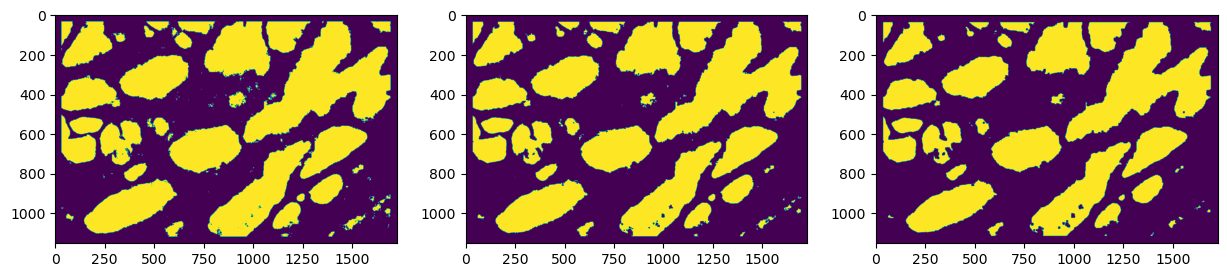

In [50]:
#################
## POLISH MASK ##
#################

## Downscale factor
ds = 4

## Binarise mask
mask_bin = ((mask > 0)*1).astype('uint8')
mask_bin = cv2.resize(mask_bin, (int(mask_bin.shape[1]/ds), int(mask_bin.shape[0]/ds)))
mask_bin = mask_bin[:,:,None]

## Polish mask
mask_bin_polished = polish(mask_bin)
mask_bin_polished_polished = polish(mask_bin_polished)

## Visualise
fig, axes = plt.subplots(1, 3, figsize=(15,5))
axes[0].imshow(mask_bin)
axes[1].imshow(mask_bin_polished)
axes[2].imshow(mask_bin_polished_polished)
plt.show()
plt.close()

#
###

267
77
56


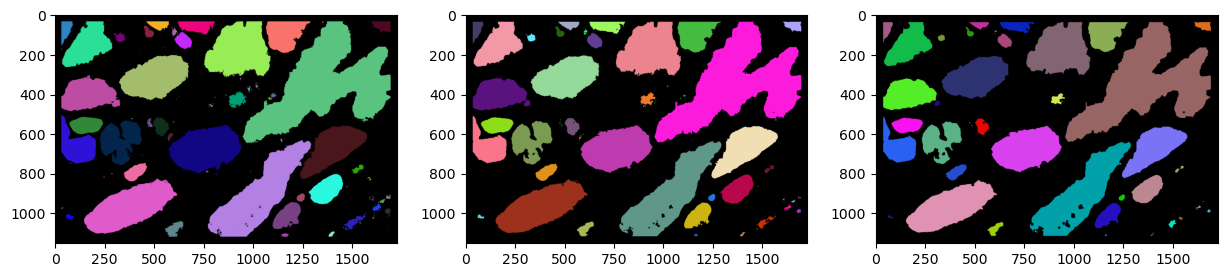

In [52]:
#####################
## EXTRACT OBJECTS ##
#####################

## Get objects
gland_coords = extract_object_pixels(mask_bin)
gland_coords_polished = extract_object_pixels(mask_bin_polished)
gland_coords_polished_polished = extract_object_pixels(mask_bin_polished_polished)
print(len(gland_coords))
print(len(gland_coords_polished))
print(len(gland_coords_polished_polished))

## Rescale coordinates to original size
rescaled_gland_coords = [coords * ds for coords in gland_coords]
rescaled_gland_coords_polished = [coords * ds for coords in gland_coords_polished]
rescaled_gland_coords_polished_polished = [coords * ds for coords in gland_coords_polished_polished]

## Visualise objects
fig, axes = plt.subplots(1, 3, figsize=(15,5))
axes[0].imshow(inlay_objects(mask_bin, gland_coords))
axes[1].imshow(inlay_objects(mask_bin_polished, gland_coords_polished))
axes[2].imshow(inlay_objects(mask_bin_polished_polished, gland_coords_polished_polished))
plt.show()
plt.close()

#
###

In [59]:
##################
## SAVE OBJECTS ##
##################

## Create a folder to store extracted object images
output_folder = '/Users/willembonnaffe/Desktop/extracted_objects_3'
os.makedirs(output_folder, exist_ok=True)

## Parameters
buffer = 200
dxy = 30

## Extract and save each object
for i, coords in enumerate(rescaled_gland_coords_polished):

    ## Discard small objects
    if len(coords) > 1000:
        
        ## Get bounding box of the object
        x_min, y_min, x_max, y_max = get_bounding_box_square(coords)
    
        ## Check overlap with boundary
        
        ## Discard object if overlaps tissue boundary
        if ((x_min - buffer) > 0) & ((x_max + buffer) < img.shape[1] + 1) & ((y_min - buffer) > 0) & ((y_max + buffer) < img.shape[0] + 1):

            ## Get object
            object_img = img[(y_min - dxy):(y_max + dxy), (x_min - dxy):(x_max + dxy)]
            object_img = cv2.cvtColor(object_img, cv2.COLOR_BGR2RGB) 
    
            ## Save the object image
            object_filename = os.path.join(output_folder, f'object_{i}.png')            
            cv2.imwrite(object_filename, object_img)

            ## Update
            print(f'Saved object {i} to {object_filename}')

#
###

Saved object 9 to /Users/willembonnaffe/Desktop/extracted_objects_3/object_9.png
Saved object 11 to /Users/willembonnaffe/Desktop/extracted_objects_3/object_11.png
Saved object 12 to /Users/willembonnaffe/Desktop/extracted_objects_3/object_12.png
Saved object 13 to /Users/willembonnaffe/Desktop/extracted_objects_3/object_13.png
Saved object 20 to /Users/willembonnaffe/Desktop/extracted_objects_3/object_20.png
Saved object 30 to /Users/willembonnaffe/Desktop/extracted_objects_3/object_30.png
Saved object 31 to /Users/willembonnaffe/Desktop/extracted_objects_3/object_31.png
Saved object 34 to /Users/willembonnaffe/Desktop/extracted_objects_3/object_34.png
Saved object 36 to /Users/willembonnaffe/Desktop/extracted_objects_3/object_36.png
Saved object 37 to /Users/willembonnaffe/Desktop/extracted_objects_3/object_37.png
Saved object 47 to /Users/willembonnaffe/Desktop/extracted_objects_3/object_47.png
Saved object 52 to /Users/willembonnaffe/Desktop/extracted_objects_3/object_52.png
Saved 